In [17]:
from pathlib import Path
import pandas as pd
import numpy as np
import uproot
import matplotlib.pyplot as plt
import mplhep as hep

from llr_study import utils
from utils import functions

plt.style.use(hep.style.CMS)
label_fontsize = 18
tick_fontsize = 18
rlabel = "13.6 TeV"
legend_fontsize = 18
cms_fontsize = 18
ylabel = "normalized events"

In [16]:
%config InlineBackend.figure_format = 'retina'

In [3]:
projectdir = Path('/eos/user/a/anunezde/Z_OUTPUT_eos/Disc_Study_New')
workdirs = ['LLR_odd', 'JetTop_even']
file_paths = [projectdir / wd / 'fits_new' / 'summary_results.txt' for wd in workdirs]
df = utils.parse_UL_results_files(file_paths)
df = df[df['obs_type'] != 'llr_from_multivar']
print(df['obs_type'].value_counts())
df


Total observables parsed: 147
var_1D               69
llr_from_1D          66
llr_from_multivar    12
Name: obs_type, dtype: int64
var_1D         69
llr_from_1D    66
Name: obs_type, dtype: int64


,obs_name,mu,sigma1_min,sigma1_max,sigma2_min,sigma2_max,obs_type,n_variables
11,jj_l_dR,403.5,289.9,562.7,218.3,752.1,var_1D,1
12,jj_lnu_dR,409.2,294.1,570.7,221.4,762.9,var_1D,1
13,jj_l_dR_llr,421.5,302.9,587.8,228.0,785.7,llr_from_1D,1
14,jj_lnu_dR_llr,432.0,310.4,602.5,233.7,805.3,llr_from_1D,1
15,WW_mInv_llr,538.2,385.5,754.9,289.1,1013.0,llr_from_1D,1
...,...,...,...,...,...,...,...,...
142,nAK4_nonbtag,4000.0,3453.0,6902.0,2570.0,9492.0,var_1D,1
143,met_phi_llr,4000.0,3988.0,8050.0,3609.0,12130.0,llr_from_1D,1
144,nAK4_btag_llr,4000.0,3985.0,8050.0,3766.0,12130.0,llr_from_1D,1
145,nAK4_nonbtag_llr,4000.0,2943.0,5897.0,2195.0,8125.0,llr_from_1D,1


In [4]:
vars_df = df[df['obs_type'] == 'var_1D'][['obs_name','mu']].rename(columns={'obs_name':'name','mu':'mu_raw'})
llrs_df = df[df['obs_type'] == 'llr_from_1D'][['obs_name','mu']].rename(columns={'obs_name':'name','mu':'mu_llr'})
llrs_df['name'] = llrs_df['name'].str.replace(r'_llr$', '', regex=True)

merged = vars_df.merge(llrs_df, on='name', how='inner')
merged['rel_gain'] = (merged['mu_raw'] - merged['mu_llr'])/merged['mu_raw']

# First-pass curated list: requires a noticeable LR gain and no saturation
curated_1D = (merged
              .query('mu_llr < 3500 and rel_gain >= 0.10')
              .sort_values('mu_llr')
              .reset_index(drop=True))

# These are the observables you’ll favor as 1D ingredients
curated_list = curated_1D['name'].tolist()

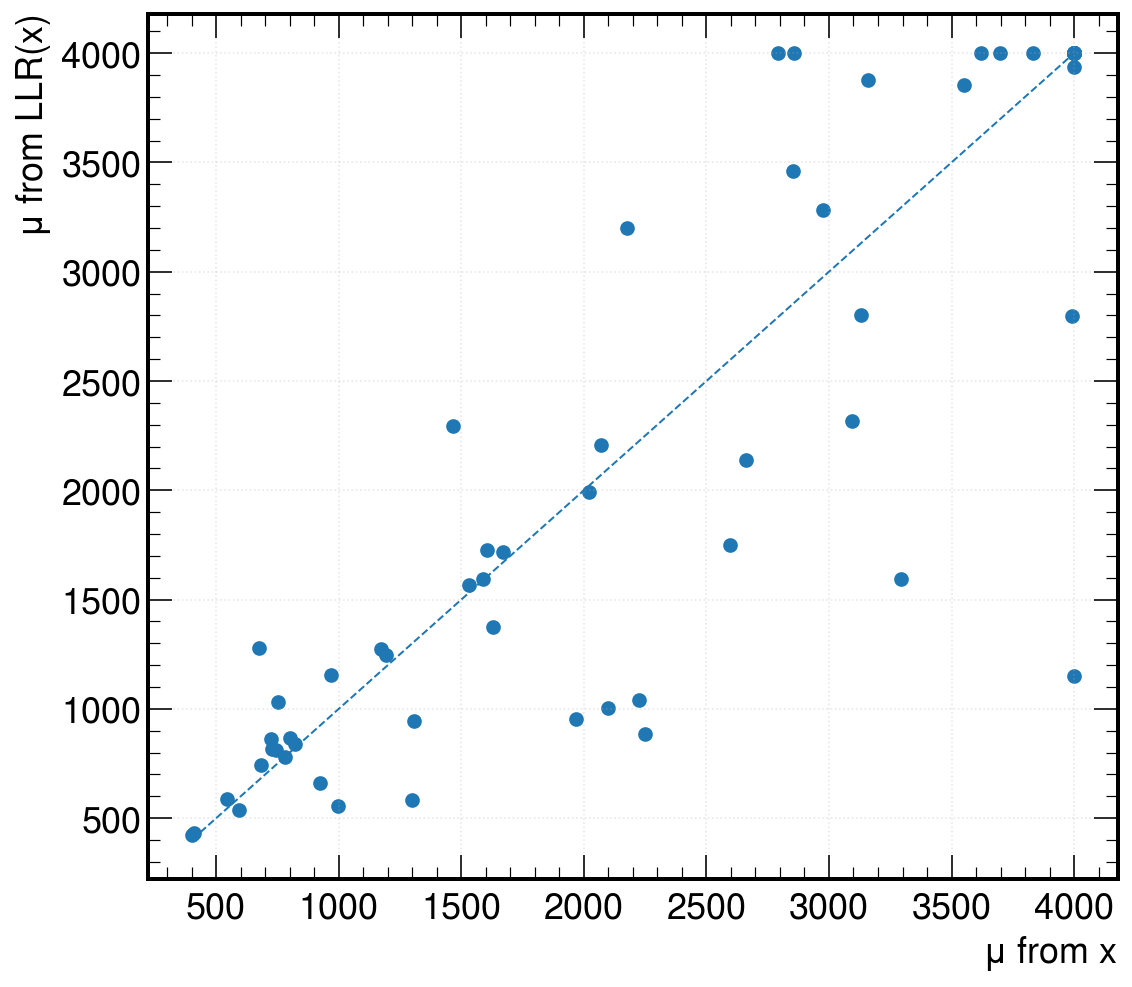

In [8]:
# Scatter plot
fig, ax = plt.subplots(figsize=(8,7))
ax.scatter(merged['mu_raw'], merged['mu_llr'], s=40)
ax.plot([merged['mu_raw'].min(), merged['mu_raw'].max()],
        [merged['mu_raw'].min(), merged['mu_raw'].max()],
        linestyle='--', linewidth=1)
ax.set_xlabel(r'$\mu$ from x', fontsize=legend_fontsize)
ax.set_ylabel(r'$\mu$ from $\mathrm{LLR}(x)$', fontsize=legend_fontsize)
ax.tick_params(axis='both', labelsize=tick_fontsize)
ax.grid(True, alpha=0.3)
plt.savefig('raw_vs_llr_scatter.pdf', dpi=300, bbox_inches='tight')
plt.tight_layout()

In [26]:
curated_1D

,name,mu_raw,mu_llr,rel_gain
0,jj_lnu_dPhi,997.9,554.9,0.443932
1,bjets_pt_bb,1301.0,581.8,0.552806
2,bjets_dR,924.2,661.8,0.283921
3,bjets_mbb,2248.0,883.8,0.606851
4,bjets_dPhi,1306.0,945.8,0.275804
5,bb_lnu_dPhi,1969.0,951.9,0.516557
6,bjet_bijet_dR,2098.0,1004.0,0.521449
7,bb_lnu_dR,2225.0,1040.0,0.532584
8,blnu_pt,4000.0,1152.0,0.712000
9,bjets_mean_pt,1628.0,1376.0,0.154791


In [8]:
curated_list

['jj_lnu_dPhi',
 'bjets_pt_bb',
 'bjets_dR',
 'bjets_mbb',
 'bjets_dPhi',
 'bb_lnu_dPhi',
 'bjet_bijet_dR',
 'bb_lnu_dR',
 'blnu_pt',
 'bjets_mean_pt',
 'bjets_dEta',
 'trijet_bijet_dEta',
 'met_pt',
 'blnu_mT',
 'all_sT',
 'all_jets_HT']


Total observables parsed: 798
llr_from_3D    543
llr_from_2D    120
var_1D          69
llr_from_1D     66
Name: obs_type, dtype: int64
llr_from_3D    543
llr_from_2D    120
var_1D          69
llr_from_1D     66
Name: obs_type, dtype: int64


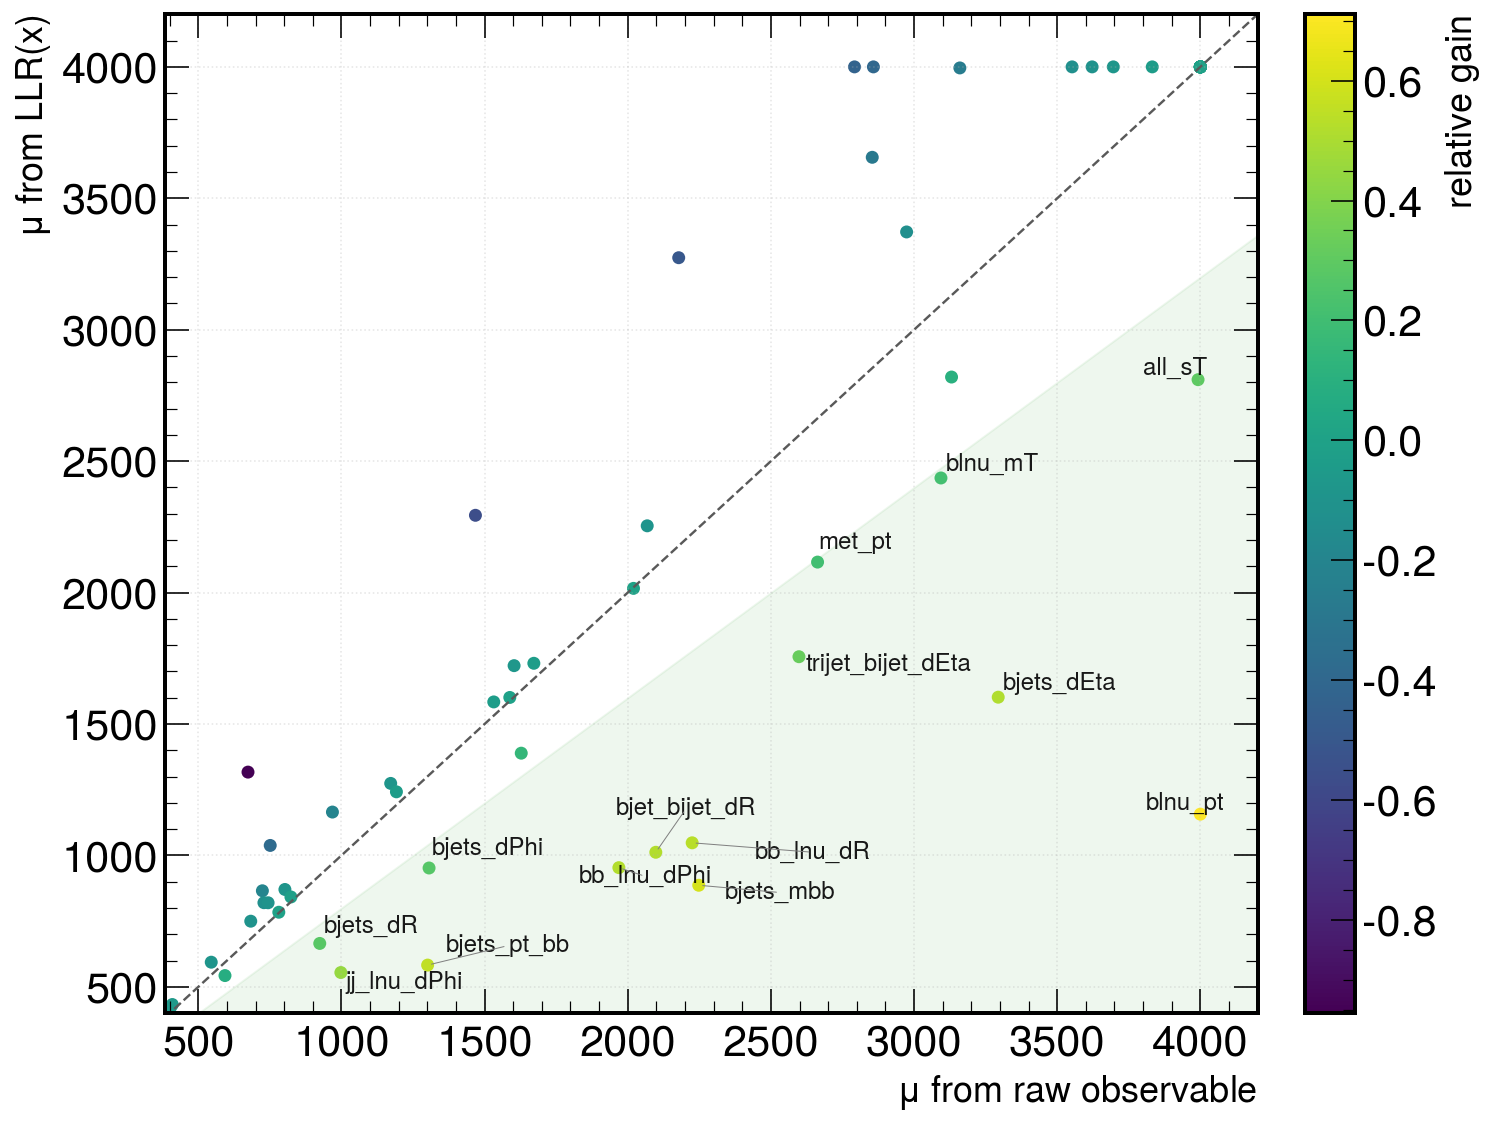

In [61]:
workdirs = ['LLR_crtd_odd', 'JetTop_even']
file_paths = [projectdir / wd / 'fits_new' / 'summary_results.txt' for wd in workdirs]
df = utils.parse_UL_results_files(file_paths)
df = df[df['obs_type'] != 'llr_from_multivar']
print(df['obs_type'].value_counts())

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from adjustText import adjust_text

# --- build merged + rel_gain exactly as you already do ---
vars_df = df[df['obs_type'] == 'var_1D'][['obs_name','mu']].rename(columns={'obs_name':'name','mu':'mu_raw'})
llrs_df = df[df['obs_type'] == 'llr_from_1D'][['obs_name','mu']].rename(columns={'obs_name':'name','mu':'mu_llr'})
llrs_df['name'] = llrs_df['name'].str.replace(r'_llr$', '', regex=True)

merged = vars_df.merge(llrs_df, on='name', how='inner').copy()
merged['rel_gain'] = (merged['mu_raw'] - merged['mu_llr'])/merged['mu_raw']

# curated rule (used for shading/legend only)
cut_mu = 3500.0
cut_gain = 0.2
cut_gain_cmp = 1 - cut_gain
mask_keep = (merged['mu_llr'] < cut_mu) & (merged['rel_gain'] >= cut_gain)

# ---------------------- figure with marginals ----------------------
plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.3})
fig = plt.figure(figsize=(14, 12))
gs = gridspec.GridSpec(
    2, 2, width_ratios=[4, 1.1], height_ratios=[1.1, 4],
    wspace=0.05, hspace=0.05
)

ax_scatter = fig.add_subplot(gs[1,0])

x = merged['mu_raw'].values
y = merged['mu_llr'].values
c = merged['rel_gain'].values  # color by relative gain

# main scatter, colored by rel_gain
sc = ax_scatter.scatter(x, y, c=c, s=42, cmap='viridis', edgecolor='none')

# 1: diagonal (LLR=raw) and gain line (LLR = 0.9 * raw)
xmin, xmax = x.min()*0.95, x.max()*1.05
xx = np.linspace(xmin, xmax, 200)
ax_scatter.plot(xx, xx, linestyle='--', linewidth=1.2, color='0.35', label=r'$y=x$')

# shade the “kept” region: y <= min(0.9x, 3500)
yy_keep = np.minimum(cut_gain_cmp*xx, cut_mu)
ax_scatter.fill_between(xx, 0, yy_keep, color='tab:green', alpha=0.08, zorder=0)

# 3: annotate the top N improvers
N_anno = 14
top = merged.sort_values('rel_gain', ascending=False).head(N_anno)
texts = []
for _, r in top.iterrows():
    texts.append(
        ax_scatter.text(
            r['mu_raw'], r['mu_llr'], r['name'],
            fontsize=12, color='black', alpha=0.9
        )
    )

for t in texts:
    if t.get_text() in ["all_sT", "blnu_pt"]:
        t.set_x(t.get_position()[0] - 200)  # move left

adjust_text(
    texts, ax=ax_scatter,
    arrowprops=dict(arrowstyle='-', color='0.5', lw=0.5),
    expand_points=(1.2,1.2),   # repel from points
    expand_axes=(1.2,1.2)      # repel from axes
)

# labels, limits, legend, colorbar
ax_scatter.set_xlabel(r'$\mu$ from raw observable', fontsize=label_fontsize)
ax_scatter.set_ylabel(r'$\mu$ from $\mathrm{LLR}(x)$', fontsize=label_fontsize)
ax_scatter.set_xlim(xmin, xmax)
ymin, ymax = y.min()*0.95, y.max()*1.05
ax_scatter.set_ylim(ymin, ymax)

cb = fig.colorbar(sc, ax=ax_scatter, fraction=0.046, pad=0.04)
cb.set_label(r'relative gain', fontsize=label_fontsize)

plt.savefig('raw_vs_llr_scatter.pdf', dpi=300, bbox_inches='tight')
plt.show()

In [69]:
curated = merged[mask_keep]
len(curated)
curated['name'].values

array(['bjets_dR', 'jj_lnu_dPhi', 'bjets_pt_bb', 'bjets_dPhi',
       'bb_lnu_dPhi', 'bjet_bijet_dR', 'bb_lnu_dR', 'bjets_mbb',
       'trijet_bijet_dEta', 'met_pt', 'blnu_mT', 'bjets_dEta', 'all_sT',
       'blnu_pt'], dtype=object)

### Curated Vars Diagnostics

In [9]:
resultsdir = projectdir / 'JetTop_even' / 'results'
eras = functions.get_eras(resultsdir)
signal_files = functions.filter_files_by_process_and_era(resultsdir, ['ggHH_kl_1_kt_1_bbww'], eras)
bkg_files = functions.filter_files_by_process_and_era(resultsdir, ['ttbar','tW'], eras)

In [ ]:
sig = utils.get_branch_as_df(signal_files, 'SL_4j_resolved', curated_list)
bkg = utils.get_branch_as_df(bkg_files, 'SL_4j_resolved', curated_list)

corr_S = sig.corr(method='spearman')
corr_B = bkg.corr(method='spearman')
delta_corr = (corr_S - corr_B).abs()  # magnitude of difference

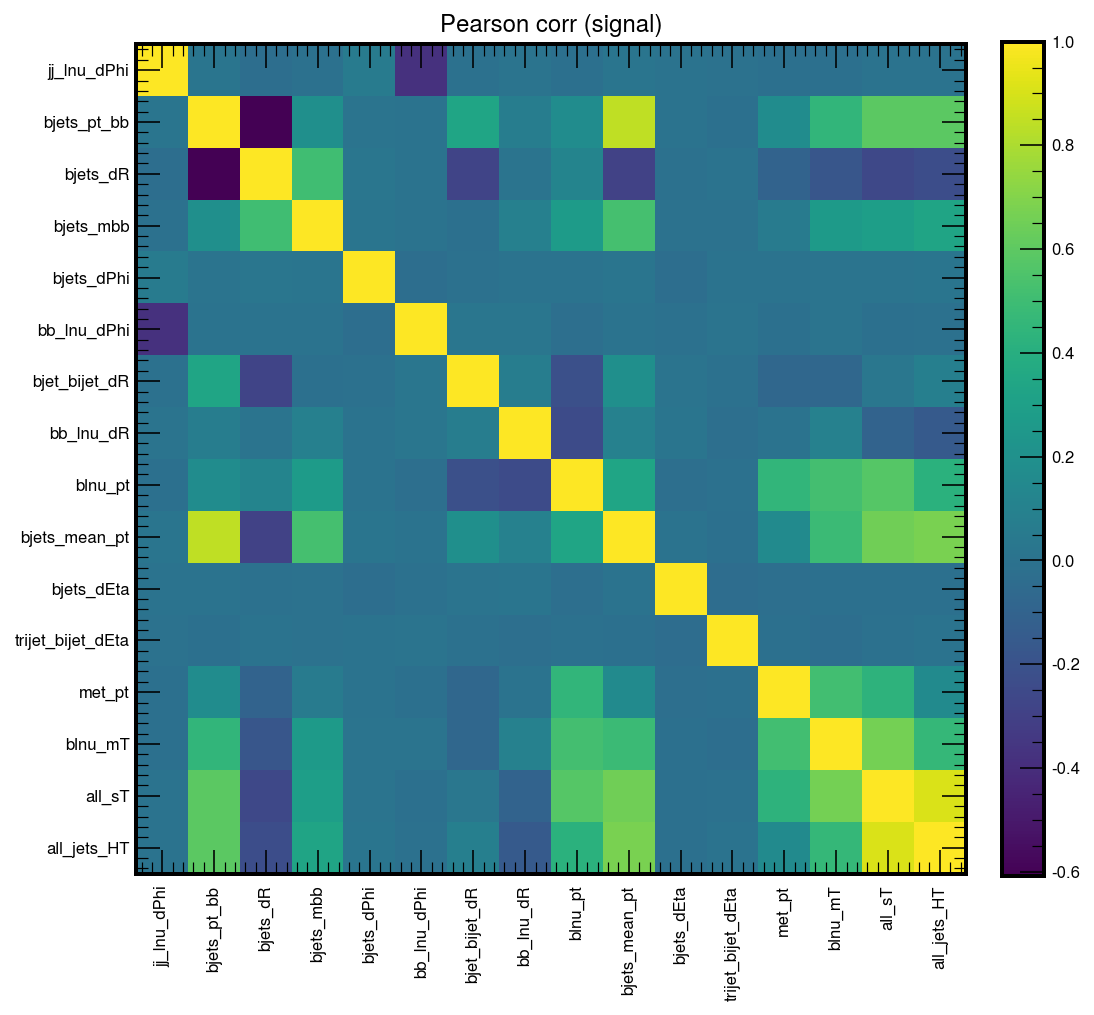

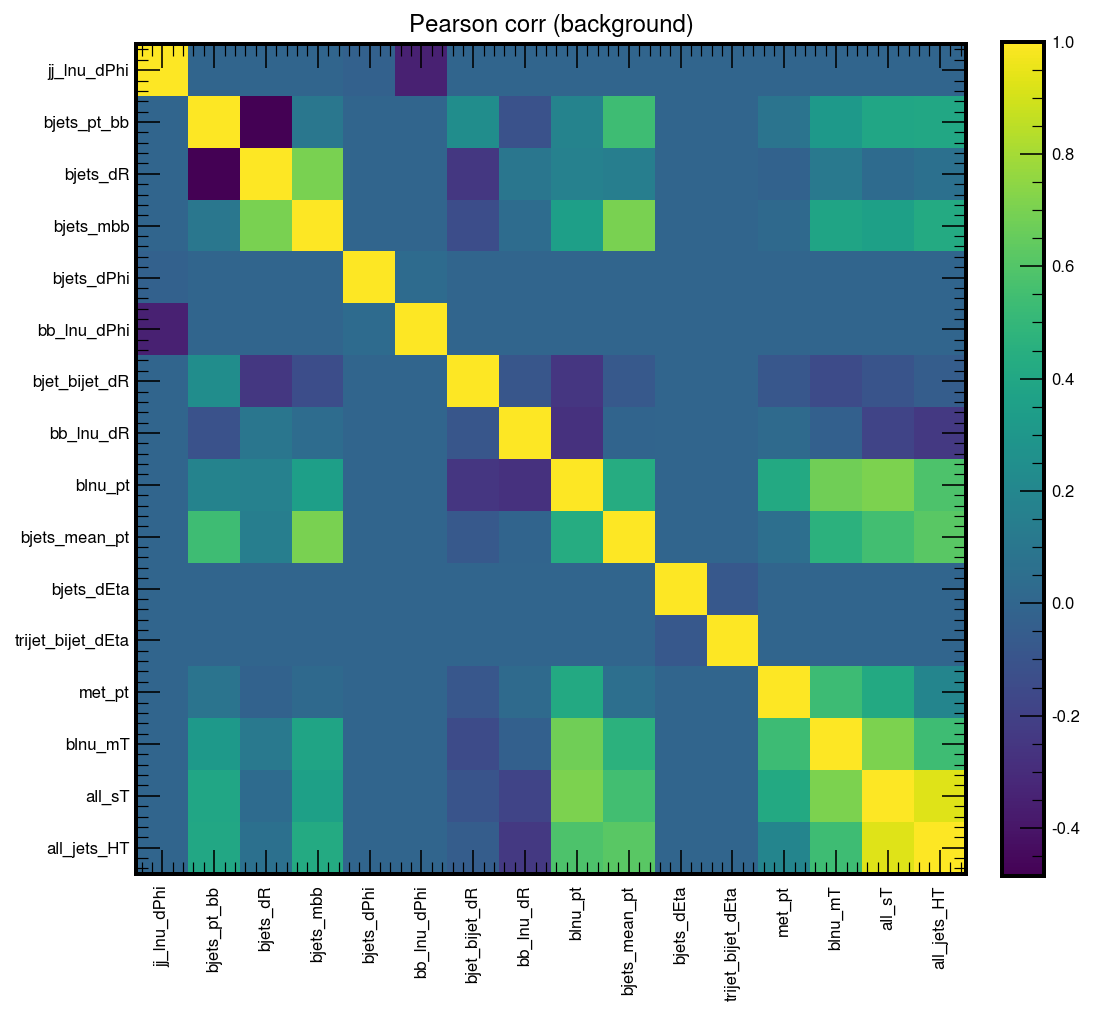

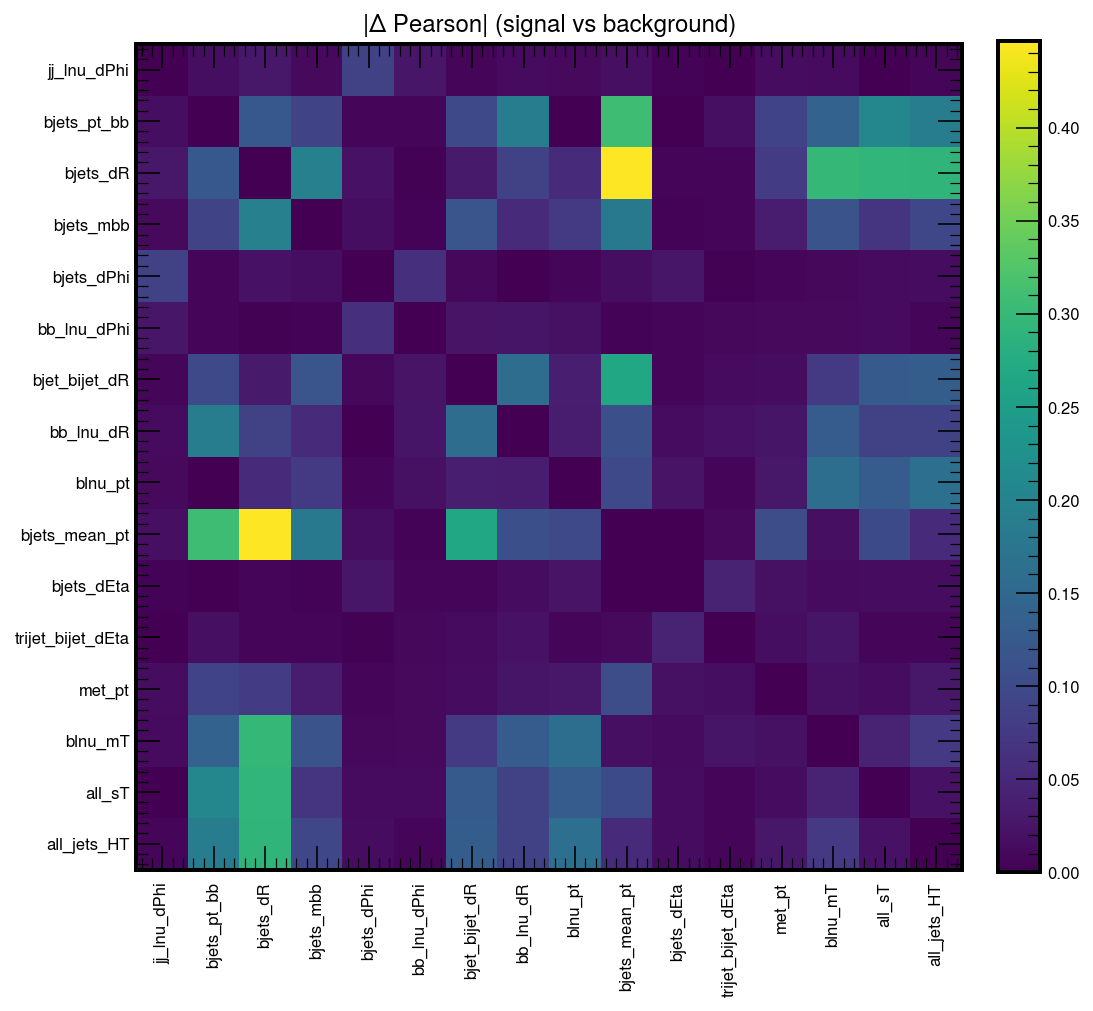

In [25]:
def heatmap(mat, title):
    fig, ax = plt.subplots(figsize=(0.5+0.45*len(curated_list), 0.5+0.45*len(curated_list)))
    im = ax.imshow(mat.values, cmap='viridis')
    ax.set_xticks(range(len(curated_list))); ax.set_yticks(range(len(curated_list)))
    ax.set_xticklabels(curated_list, rotation=90); ax.set_yticklabels(curated_list)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(title); plt.tight_layout()

heatmap(corr_S, "Pearson corr (signal)")
heatmap(corr_B, "Pearson corr (background)")
heatmap(delta_corr,  "|Δ Pearson| (signal vs background)")

In [33]:
import itertools as it

def rank_pairs(delta_corr: pd.DataFrame,
               variables: list[str],
               top_n: int = 20,
               corr_S: pd.DataFrame = None,
               corr_B: pd.DataFrame = None,
               min_abs_corr: float = 0.0):
    """
    Rank observable pairs by |Δ correlation| = |ρ_S - ρ_B|.
    Optionally require at least one class to have |ρ| >= min_abs_corr.
    """
    rows = []
    for a, b in it.combinations(variables, 2):
        d = float(delta_corr.loc[a, b])
        # optional gating: skip pairs that are nearly uncorrelated in BOTH classes
        if corr_S is not None and corr_B is not None and min_abs_corr > 0:
            if (abs(corr_S.loc[a, b]) < min_abs_corr) and (abs(corr_B.loc[a, b]) < min_abs_corr):
                continue
        rows.append({"var1": a, "var2": b, "delta_corr": d})
    df = pd.DataFrame(rows).sort_values("delta_corr", ascending=False, ignore_index=True)
    return df.head(top_n), df

def rank_triplets(delta_corr: pd.DataFrame,
                  variables: list[str],
                  top_n: int = 20,
                  agg: str = "mean",   # "mean" | "min" | "geom"
                  corr_S: pd.DataFrame = None,
                  corr_B: pd.DataFrame = None,
                  min_abs_corr: float = 0.0):
    """
    Rank observable triplets using an aggregate score of the three pairwise |Δ correlations|.
      - agg="mean": average of (Δ12, Δ13, Δ23)  ← good default
      - agg="min":  conservative; requires all three pairs to have sizable Δ
      - agg="geom": geometric mean; penalizes any near-zero Δ
    Optionally require at least ONE pair in the triplet to have |ρ| >= min_abs_corr in either class.
    """
    rows = []
    for a, b, c in it.combinations(variables, 3):
        d12 = abs(float(delta_corr.loc[a, b]))
        d13 = abs(float(delta_corr.loc[a, c]))
        d23 = abs(float(delta_corr.loc[b, c]))

        if agg == "mean":
            score = np.mean([d12, d13, d23])
        elif agg == "min":
            score = min(d12, d13, d23)
        elif agg == "geom":
            score = (d12 * d13 * d23) ** (1 / 3)
        else:
            raise ValueError("agg must be 'mean', 'min', or 'geom'")

        # optional gating: require at least one pair to be non-trivially correlated in S or B
        if corr_S is not None and corr_B is not None and min_abs_corr > 0:
            any_corr = False
            for u, v in [(a, b), (a, c), (b, c)]:
                if (abs(corr_S.loc[u, v]) >= min_abs_corr) or (abs(corr_B.loc[u, v]) >= min_abs_corr):
                    any_corr = True
                    break
            if not any_corr:
                continue

        rows.append({
            "var1": a, "var2": b, "var3": c,
            "score": score, "d12": d12, "d13": d13, "d23": d23
        })

    df = pd.DataFrame(rows).sort_values("score", ascending=False, ignore_index=True)
    return df.head(top_n), df

In [45]:
top_pairs, all_pairs = rank_pairs(delta_corr, curated_list, top_n=20, corr_S=corr_S, corr_B=corr_B, min_abs_corr=0.10)
top_triplets, all_triplets = rank_triplets(delta_corr, curated_list, top_n=20, agg="mean", corr_S=corr_S, corr_B=corr_B, min_abs_corr=0.10)

all_pairs.to_csv("llr_study/curated_pairs_by_delta.csv", index=False)
all_triplets.to_csv("llr_study/curated_triplets_by_delta.csv", index=False)